Problem set 1: Simulating Customer Clicks Using a Bernoulli Random Variable
<br>Problem statement
An organization sends promotional emails. Historical data indicate that a customer clicks the link with probability p=0.30.<br>
Define:<br>
X={1, customer clicks 0, customer does not click <br>
Thus,<br>
X∼Bernoulli0.30<br>
tasks<br>
Step 1: Identify the random variable<br>
Answer the following:<br>
What does X=1represent? <br>
What does X=0represent? <br>
What are the possible values of X? <br>
Is Xa discrete or continuous random variable? <br>
Which probability distribution is suitable for X?<br>


In [67]:
import numpy as np
from scipy.stats import bernoulli

p = 0.30
X = bernoulli(p)

# X = 1
print("X = 1 : the customer clicks the link\n")

# X = 0
print("X = 0 : the customer does not click the link\n")

support = [0, 1]
print("values of X:", support)

# Discrete or continuous?
print("\nType: Discrete random variable") ## countable set = discrete

print("\nDistribution: Bernoulli(p = 0.30)")

print("\nP(X = 0):", X.pmf(0))
print("P(X = 1):", X.pmf(1))
print("PMF: ", X.pmf(0) + X.pmf(1))

X = 1 : the customer clicks the link

X = 0 : the customer does not click the link

values of X: [0, 1]

Type: Discrete random variable

Distribution: Bernoulli(p = 0.30)

P(X = 0): 0.7000000000000002
P(X = 1): 0.3
PMF:  1.0000000000000002


Step 2: Write the theoretical PMF<br><br>
Step 3: Generate outcomes for 20 customers. Hint: np.random.binomial(n=1, ...) generates Bernoulli observations because only one trial is performed for each customer.<br>
Use code: samples = np.random.binomial( n=1, p=p, size=sample_size )<br>
Answer the following:<br>
How many observations were generated? <br>
What does each zero represent? <br>
What does each one represent? <br>
Are your generated observations the same as the theoretical probabilities?<br>


In [68]:
# P(X = x) = p^x * (1 - p)^(1 - x),  x in {0, 1}
def pmf(x, p):
    return (p ** x) * ((1 - p) ** (1 - x))

print("Theoretical PMF")
for x in [0, 1]:
    print(f"P(X = {x}) = {pmf(x, p):.2f}")

print("scipy check:", X.pmf(0), X.pmf(1))



Theoretical PMF
P(X = 0) = 0.70
P(X = 1) = 0.30
scipy check: 0.7000000000000002 0.3


In [69]:
sample_size = 20
np.random.seed(42)
samples = np.random.binomial(n=1, p=p, size=sample_size)
print("\nGenerated samples:", samples)

print("Number of observations:", len(samples))

zeros = np.sum(samples == 0)
ones = np.sum(samples == 1)
print("Number of zeros (no click):", zeros)
print("Number of ones (click):", ones)

print(f"\nTheoretical = {pmf(0, p):.2f}")
print(f"Theoretical = {pmf(1, p):.2f}")


Generated samples: [0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0]
Number of observations: 20
Number of zeros (no click): 14
Number of ones (click): 6

Theoretical = 0.70
Theoretical = 0.30


How many customers clicked? - 9 <br>
How many customers did not click? - 11 <br>
Do the two counts add up to 20? - 20<br>


In [70]:
print("Total clicks: ", ones + zeros)

Total clicks:  20


In [71]:
noc = ones + zeros
# ---------- Step 5: Empirical PMF ----------
empirical_p1 = noc / sample_size
empirical_p0 = zeros / sample_size

print("Empirical PMF")
print("P(X = 0) =", empirical_p0)
print("P(X = 1) =", empirical_p1)


Empirical PMF
P(X = 0) = 0.7
P(X = 1) = 1.0


In [72]:
# ---------- Step 6: Compare empirical and theoretical ----------
theoretical_p0 = pmf(0, p)
theoretical_p1 = pmf(1, p)

print("\nComparison")
print(f"P(X=0): empirical = {empirical_p0:.2f}, theoretical = {theoretical_p0:.2f}")
print(f"P(X=1): empirical = {empirical_p1:.2f}, theoretical = {theoretical_p1:.2f}")
print("Difference for P(X=1):", abs(empirical_p1 - theoretical_p1))


Comparison
P(X=0): empirical = 0.70, theoretical = 0.70
P(X=1): empirical = 1.00, theoretical = 0.30
Difference for P(X=1): 0.7


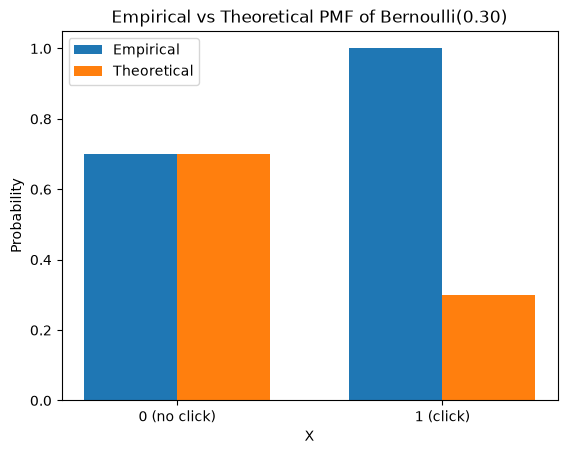

In [73]:
# ---------- Step 7: Plot both PMFs ----------
import matplotlib.pyplot as plt
x_values = np.array([0, 1])
empirical = [empirical_p0, empirical_p1]
theoretical = [theoretical_p0, theoretical_p1]

width = 0.35
plt.bar(x_values - width/2, empirical, width, label="Empirical")
plt.bar(x_values + width/2, theoretical, width, label="Theoretical")
plt.xticks([0, 1], ["0 (no click)", "1 (click)"])
plt.xlabel("X")
plt.ylabel("Probability")
plt.title("Empirical vs Theoretical PMF of Bernoulli(0.30)")
plt.legend()
plt.show()

In [74]:
# ---------- Step 8: Theoretical expectation ----------
# E[X] = sum of x * P(X = x) = p
theoretical_mean = 0 * theoretical_p0 + 1 * theoretical_p1
print("\nTheoretical E[X] =", theoretical_mean)

# ---------- Step 9: Empirical expectation ----------
empirical_mean = np.mean(samples)
print("Empirical E[X]   =", empirical_mean)


Theoretical E[X] = 0.3
Empirical E[X]   = 0.3


In [75]:
# ---------- Step 10: Theoretical variance ----------
# Var(X) = p(1 - p)
theoretical_var = p * (1 - p)
print("\nTheoretical Var(X) =", theoretical_var)


Theoretical Var(X) = 0.21


In [76]:
# ---------- Step 11: Empirical variance ----------
empirical_var = np.var(samples)
print("Empirical variance:", empirical_var)

Empirical variance: 0.20999999999999996


In [78]:
# ---------- Step 12: Final result table ----------
rows = [
    ("P(X=0)",      pmf(0, p),   zeros/ sample_size),
    ("P(X=1)",      pmf(1, p),  ones / sample_size),
    ("Expectation", p,           np.mean(samples)),
    ("Variance",    p * (1 - p), empirical_var),
]

print(f"\n{'Measure':<12}{'Theoretical':>13}{'Empirical':>12}{'Abs. diff':>12}")
for name, t, e in rows:
    print(f"{name:<12}{t:>13.4f}{e:>12.4f}{abs(t - e):>12.4f}")


Measure       Theoretical   Empirical   Abs. diff
P(X=0)             0.7000      0.7000      0.0000
P(X=1)             0.3000      0.3000      0.0000
Expectation        0.3000      0.3000      0.0000
Variance           0.2100      0.2100      0.0000


In [84]:
# ---------- Step 13: Effect of sample size ----------
np.random.seed(42)
print(f"\n{'n':>8}{'P(X=0)':>10}{'P(X=1)':>10}{'Mean':>10}{'Variance':>10}")
for n in [10, 100, 1000, 10000]:
    s = np.random.binomial(n=1, p=p, size=n)
    print(f"{n:>8}{np.mean(s == 0):>10.4f}{np.mean(s == 1):>10.4f}{np.mean(s):>10.4f}{np.var(s):>10.4f}")


       n    P(X=0)    P(X=1)      Mean  Variance
      10    0.6000    0.4000    0.4000    0.2400
     100    0.7200    0.2800    0.2800    0.2016
    1000    0.7030    0.2970    0.2970    0.2088
   10000    0.7094    0.2906    0.2906    0.2062


<h1> Part 2